# Re training the Model with a Larger Dataset

In [2]:
! pip install --only-binary :all: umap-learn

In [51]:
! pip install --upgrade pip
! pip install pandas
! pip install scikit-learn
! pip install hdbscan 
! pip install matplotlib
! pip install --only-binary :all: umap-learn
! pip install seaborn
! pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 24.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


# Imports

In [2]:
import re
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import hstack, csr_matrix

# Use GCP pipeline so features match production exactly
gcp_dir = os.path.join(os.getcwd(), 'GCP-VM-Pipeline ')
if gcp_dir not in sys.path:
    sys.path.insert(0, gcp_dir)

from pipeline import parse_nginx_lines, make_5min_windows
from hdbscan import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Imports OK")

Imports OK


# Load + Data Cleanup

In [23]:
DATASETS = 'Datasets'
PREFIX_RE = re.compile(r'^/[^:]+:')  # strips "/var/log/nginx/access.log.1:" prefix

# shared request parser (same logic as pipeline)
_REQ_RE = re.compile(r"^(?P<method>[A-Z]+)\s+(?P<path>\S+)\s+HTTP\/")
def _parse_req(line):
    m = _REQ_RE.search(str(line))
    if not m: return ("UNK", "/")
    path = m.group("path").split("?")[0]
    return m.group("method"), re.sub(r"\d+", "0", path)

# ── 1. Standard nginx logs ─────────────────────────────────────────────────────
NGINX_LOGS = [
    'access_last10days(BunnyCDN).log',
    'nginx_access_16Jan(No CDN).log',
    'nginx_access_21Feb-7Mar_2026.log',
    'nginx_errors_21Feb-7Mar_2026.log'
]
dfs = []
for fname in NGINX_LOGS:
    with open(os.path.join(DATASETS, fname), 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    part = parse_nginx_lines(lines)
    print(f'{fname}: {len(part):,} rows')
    dfs.append(part)

# ── 2. Cloudflare nginx log (has "filepath:" prefix on each line) ──────────────
CF_LOG = os.path.join(DATASETS, 'nginx_access_19Dec-27Dec_2025(Cloudflare).log')
with open(CF_LOG, 'r', encoding='utf-8', errors='ignore') as f:
    cf_lines = [PREFIX_RE.sub('', line) for line in f.readlines()]
df_cf = parse_nginx_lines(cf_lines)
print(f'nginx_access_19Dec-27Dec_2025(Cloudflare).log: {len(df_cf):,} rows')
dfs.append(df_cf)

# # ── 3. honeypot_logs.csv (CSV with header; IP column has filepath prefix) ──────
# CSV_LOG = os.path.join(DATASETS, 'honeypot_logs.csv')
# raw = pd.read_csv(CSV_LOG, header=0, encoding='utf-8-sig')
# raw["client_ip"] = raw["Log Source and Client IP"].astype(str).str.split(":").str[-1].str.strip()
# ts = raw["Timestamp"].astype(str).str.strip("[] ").str.strip()
# raw["Timestamp"] = pd.to_datetime(ts, format="%d/%b/%Y:%H:%M:%S", errors="coerce", utc=True)
# raw["HTTP Status Code"] = pd.to_numeric(raw["HTTP Status Code"], errors="coerce")
# raw["Response size (bytes)"] = pd.to_numeric(raw["Response size (bytes)"], errors="coerce").fillna(0)
# raw[["http_method", "http_path"]] = raw["HTTP Request Line"].apply(lambda x: pd.Series(_parse_req(x)))
# df_csv = raw.dropna(subset=["Timestamp", "client_ip", "HTTP Status Code"])[
#     ["client_ip", "Timestamp", "HTTP Status Code", "Response size (bytes)", "http_method", "http_path", "User-Agent"]
# ].reset_index(drop=True)
# print(f'honeypot_logs.csv: {len(df_csv):,} rows')
# dfs.append(df_csv)

# ── 4. Combine all datasets ────────────────────────────────────────────────────
df = pd.concat(dfs, ignore_index=True)
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'\nCombined total: {len(df):,} rows')
print(f'Date range:     {df["Timestamp"].min()} → {df["Timestamp"].max()}')
df.head(3)

access_last10days(BunnyCDN).log: 10,431 rows
nginx_access_16Jan(No CDN).log: 300 rows
nginx_access_21Feb-7Mar_2026.log: 34,825 rows
nginx_errors_21Feb-7Mar_2026.log: 0 rows
nginx_access_19Dec-27Dec_2025(Cloudflare).log: 3,621 rows

Combined total: 49,177 rows
Date range:     2025-12-14 03:42:50+00:00 → 2026-03-07 10:16:47+00:00


,client_ip,Timestamp,HTTP Status Code,Response size (bytes),http_method,http_path,User-Agent
0,194.180.49.173,2025-12-14 03:42:50+00:00,404,147,GET,/api/.env,python-httpx/0.28.1
1,194.180.49.173,2025-12-14 04:06:11+00:00,404,147,GET,/api/.env,python-httpx/0.28.1
2,172.64.198.125,2025-12-14 04:27:51+00:00,404,147,GET,/api/.env,python-httpx/0.28.1


# parse request line into method + path 

# Break Requests down into sessions

In [24]:
windows = make_5min_windows(df)
print(f'5-min windows: {len(windows):,}')
windows.head(3)

5-min windows: 4,133


,client_ip,window_start,request_count,unique_paths,unique_methods,status_200,status_401,status_403,status_404,status_429,status_500,avg_response_size,std_response_size,paths,uas,ratio_4xx,ratio_429,ratio_5xx,path_text
0,1.24.16.102,2026-03-05 16:05:00+00:00,1,1,1,1,0,0,0,0,0,1708.0,0.0,[/],[Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537....,0.0,0.0,0.0,/
1,1.24.16.50,2026-02-28 10:15:00+00:00,2,1,1,2,0,0,0,0,0,1708.0,0.0,"[/, /]",[Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537....,0.0,0.0,0.0,/ /
2,1.252.194.4,2026-02-28 20:30:00+00:00,2,1,1,0,0,0,0,0,0,169.0,0.0,"[/, /]","[-, -]",0.0,0.0,0.0,/ /


# Train - Test Data Split

In [25]:
# HDBSCAN is unsupervised — train on all windows, no held-out test set needed
train_data = windows.copy()
print(f'Training windows: {len(train_data):,}')

Training windows: 4,133


# Feature Pre-processing (Scaling and Vectorisation)

In [26]:
# Feature engineering — must match production pipeline exactly
num_cols = [
    "request_count", "unique_paths", "unique_methods",
    "status_200", "status_401", "status_403", "status_404",
    "status_429", "status_500",
    "avg_response_size", "std_response_size",
    "ratio_4xx", "ratio_429", "ratio_5xx",
]

train_data["path_text"] = train_data["paths"].apply(lambda xs: " ".join(map(str, xs)))

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    token_pattern=r"[^\/\s]+",
    min_df=2,
)
scaler = StandardScaler()

X_txt = tfidf.fit_transform(train_data["path_text"].fillna(""))
X_num = scaler.fit_transform(train_data[num_cols].fillna(0))
X_train = hstack([X_txt, csr_matrix(X_num)])

print(f'X_train shape: {X_train.shape}')

X_train shape: (4133, 514)


# Pick best K based off silhoette score

In [27]:
import numpy as np
import pandas as pd
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ---- search space (tune ranges to your traffic volume) ----
MCS = [10, 20, 30, 50, 80, 120, 200]
MS  = [None, 5, 10, 20]

rows = []

for mcs in MCS:
    for ms in MS:
        hdb = HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            # If X_train is TF-IDF / sparse text, cosine is usually a better default than euclidean.
            # If X_train is dense numeric, keep euclidean.
            metric="cosine" if hasattr(X_train, "tocsr") or "scipy.sparse" in str(type(X_train)) else "euclidean"
        )

        labels = hdb.fit_predict(X_train)

        mask = labels != -1
        n_points = len(labels)
        n_noise = int((~mask).sum())
        noise_ratio = n_noise / n_points

        # clusters excluding noise
        n_clusters = len(set(labels[mask])) if mask.any() else 0

        # HDBSCAN stability (higher = more stable clusters)
        # cluster_persistence_ exists after fit; empty when no clusters
        stability_mean = float(np.mean(hdb.cluster_persistence_)) if n_clusters > 0 else 0.0

        sil = np.nan
        db = np.nan

        # Score only on non-noise points, and only if >=2 clusters
        if mask.sum() > 1 and n_clusters >= 2:
            X_eval = X_train[mask]
            y_eval = labels[mask]

            # silhouette supports sparse input (OK)
            sil = float(silhouette_score(X_eval, y_eval))

            # Davies-Bouldin needs dense; fall back carefully
            if hasattr(X_eval, "toarray") and X_eval.shape[1] < 2000:
                X_dense = X_eval.toarray()
            else:
                # If you have a dense numeric representation for high-dim sparse text,
                # use it here. Otherwise, skip DB.
                X_dense = X_num_train[mask] if "X_num_train" in globals() else None

            if X_dense is not None:
                db = float(davies_bouldin_score(X_dense, y_eval))

        rows.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "silhouette": sil,
            "davies_bouldin": db,
            "stability_mean": stability_mean,
        })

results = pd.DataFrame(rows)

# ---- pick "best" config with an analyst-friendly objective ----
# We want:
# - stable clusters (maximize stability_mean)
# - not too many clusters (target range)
# - not all noise
# - silhouette helps but isn't the main boss
TARGET_CLUSTERS = 20

def objective(r):
    # penalties
    cluster_penalty = abs(r["n_clusters"] - TARGET_CLUSTERS)
    noise_penalty = 0 if (0.2 <= r["noise_ratio"] <= 0.9) else 5  # keep in a plausible range
    sil_bonus = 0 if np.isnan(r["silhouette"]) else -0.5 * r["silhouette"]  # higher sil => lower objective
    # main term: prefer higher stability
    return (-2.0 * r["stability_mean"]) + cluster_penalty + noise_penalty + sil_bonus

results["objective"] = results.apply(objective, axis=1)
best = results.sort_values("objective").iloc[0]

print("Best config:")
print(best.to_string())

# Optional: show the whole table sorted
results.sort_values(["objective", "stability_mean"], ascending=[True, False])


Best config:
min_cluster_size    50.000000
min_samples               NaN
n_clusters          20.000000
noise_ratio          0.340673
silhouette           0.735630
davies_bouldin       1.698973
stability_mean       1.000000
objective           -2.367815


,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,stability_mean,objective
12,50,NaN,20,0.340673,0.735630,1.698973,1.0,-2.367815
15,50,20.0,22,0.303170,0.688468,1.096522,1.0,-0.344234
14,50,10.0,22,0.288894,0.633642,1.349941,1.0,-0.316821
13,50,5.0,24,0.257924,0.631179,1.426652,1.0,1.684410
8,30,NaN,26,0.280184,0.727679,0.906470,1.0,3.636160
19,80,20.0,14,0.349141,0.507009,1.347455,1.0,3.746495
17,80,5.0,14,0.325188,0.455350,1.497582,1.0,3.772325
18,80,10.0,13,0.317445,0.422996,1.609336,1.0,4.788502
20,120,NaN,10,0.372611,0.531727,2.845139,1.0,7.734136
16,80,NaN,10,0.364868,0.447372,2.533723,1.0,7.776314


# Fit Model

In [43]:
from hdbscan import HDBSCAN

# If you ran the previous cell, you already have:
# - results (DataFrame)
# - best (Series with min_cluster_size + min_samples)

best_mcs = 50 # int(best["min_cluster_size"])
best_ms  = 5   # None if pd.isna(best["min_samples"]) else int(best["min_samples"])

# Match the metric choice you used in the sweep
best_metric = "cosine" if hasattr(X_train, "tocsr") or "scipy.sparse" in str(type(X_train)) else "euclidean"

hdb = HDBSCAN(
    min_cluster_size=best_mcs,
    min_samples=best_ms,
    metric=best_metric,
    prediction_data=True
)

train_data["cluster"] = hdb.fit_predict(X_train)

# Cluster counts (includes -1 noise at the top)
train_data["cluster"].value_counts().sort_index()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/hdbscan/hdbscan_.py:1329: UserWarning: Metric cosine not supported for prediction data!
  warn("Metric {} not supported for prediction data!".format(self.metric))


cluster
-1     1066
 0       55
 1       67
 2      154
 3       70
 4       78
 5       76
 6      124
 7      200
 8       51
 9      204
 10     111
 11     338
 12     220
 13     104
 14     132
 15      99
 16      65
 17      70
 18      63
 19      90
 20      88
 21      53
 22     495
 23      60
Name: count, dtype: int64

In [44]:
vc = train_data["cluster"].value_counts()
out = pd.DataFrame({
    "count": vc,
    "pct": (vc / vc.sum()).round(4)
}).sort_index()

print("Noise (-1):", int(out.loc[-1, "count"]) if -1 in out.index else 0)
out


Noise (-1): 1066


,count,pct
cluster,,
-1,1066,0.2579
0,55,0.0133
1,67,0.0162
2,154,0.0373
3,70,0.0169
4,78,0.0189
5,76,0.0184
6,124,0.0300
7,200,0.0484


# Interpret Clusters

In [45]:
for c in sorted(train_data["cluster"].unique()):
    subset = train_data[train_data["cluster"] == c]
    # flatten paths
    paths = pd.Series([p for ps in subset["paths"] for p in ps])
    print(f"\nCluster {c} | n={len(subset)}")
    print("Top paths:")
    print(paths.value_counts().head(10))
    print("Avg request_count:", subset["request_count"].mean())
    print("Avg ratio_4xx:", subset["ratio_4xx"].mean())



Cluster -1 | n=1066
Top paths:
/api/auth/login                                                      1848
/                                                                     717
/favicon.ico                                                          147
/wp-login.php                                                         129
/wp-admin/index.php                                                   101
/0.php                                                                 83
/cgi-bin/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/bin/sh      59
/actuator/gateway/routes                                               57
ip.ninonakano.jp:0                                                     49
/preview.jpg                                                           46
Name: count, dtype: int64
Avg request_count: 8.517823639774859
Avg ratio_4xx: 0.030178786690692502

Cluster 0 | n=55
Top paths:
/Dr0v                           70
/attacker/docker-compose.yml     1
/config.js                    

In [65]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# X_train is the hstacked TF-IDF + numeric
X_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train

reducer = umap.UMAP(
    n_components=3,
    random_state=42,
    metric="cosine"
)

embedding = reducer.fit_transform(X_dense)

train_data["umap_x"] = embedding[:, 0]
train_data["umap_y"] = embedding[:, 1]
train_data["umap_z"] = embedding[:, 2]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


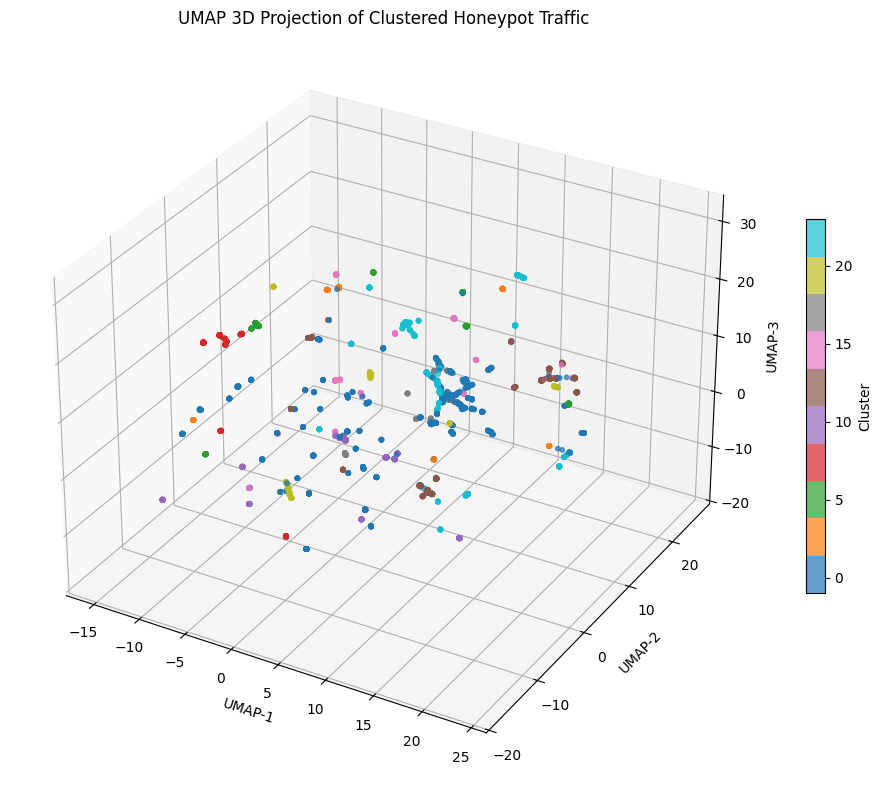

In [68]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    train_data["umap_x"],
    train_data["umap_y"],
    train_data["umap_z"],
    c=train_data["cluster"],
    cmap="tab10",
    s=10,
    alpha=0.7,
)

ax.set_title("UMAP 3D Projection of Clustered Honeypot Traffic")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")
fig.colorbar(scatter, ax=ax, label="Cluster", shrink=0.5)
plt.tight_layout()
plt.show()

In [79]:
import plotly.graph_objects as go
import numpy as np
import umap.umap_ as umap

# --- Ensure 3-D UMAP embedding exists ---
if "umap_z" not in train_data.columns:
    print("umap_z not found — computing 3-D UMAP embedding...")
    X_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
    reducer = umap.UMAP(n_components=3, random_state=42, metric="cosine")
    embedding = reducer.fit_transform(X_dense)
    train_data["umap_x"] = embedding[:, 0]
    train_data["umap_y"] = embedding[:, 1]
    train_data["umap_z"] = embedding[:, 2]
    print("Done.")

# --- Resolve cluster name mapping (most accurate source wins) ---
if "cluster_label" in train_data.columns:
    # cluster_label already merged into train_data
    name_map = train_data.groupby("cluster")["cluster_label"].first().to_dict()
    print("Using cluster_label from train_data")
else:
    try:
        # cluster_labels DataFrame defined later in notebook — use it if available
        name_map = cluster_labels.set_index("cluster")["cluster_label"].to_dict()
        print("Using cluster_labels DataFrame")
    except NameError:
        # Fallback: hardcoded names (run cells after LLM labelling for accurate names)
        name_map = {
            -1: "Noise",
             0: "Secrets Discovery (.env)",
             1: "WordPress Admin Enum",
             2: "IoT Device Login Scan",
             3: "Secrets Discovery (.env)",
             4: "Generic Login Discovery",
             5: "Generic Login Discovery",
             6: "Generic Login Discovery",
             7: "Swagger/OpenAPI Enum",
             8: "WordPress Admin Enum",
             9: "WordPress Admin Enum",
            10: "Generic Login Discovery",
            11: "PHPUnit RCE Probing",
            12: "WordPress Admin Enum",
            13: "WordPress Admin Enum",
        }
        print("Warning: cluster_labels not yet defined — using fallback names. Run LLM labelling cells first for accurate names.")

unique_clusters = sorted(train_data["cluster"].unique())

# Colour map — grey/transparent for noise, tab20 for real clusters
named_clusters = [c for c in unique_clusters if c != -1]
colors = plt.cm.tab20(np.linspace(0, 1, max(len(named_clusters), 1)))
color_map = {}
idx = 0
for c in unique_clusters:
    if c == -1:
        color_map[c] = "rgba(180,180,180,0.25)"
    else:
        r, g, b, _ = colors[idx]
        color_map[c] = f"rgba({int(r*255)},{int(g*255)},{int(b*255)},0.85)"
        idx += 1

fig = go.Figure()

for cluster_id in unique_clusters:
    mask = train_data["cluster"] == cluster_id
    subset = train_data[mask]

    label = name_map.get(cluster_id, f"Cluster {cluster_id}")
    legend_name = f"{'Noise' if cluster_id == -1 else f'C{cluster_id}'}: {label}"
    point_size  = 2 if cluster_id == -1 else 4

    # Build hover columns (use whichever exist)
    custom_cols = []
    if "ip" in subset.columns:
        custom_cols.append("ip")
    for col in ["request_count", "unique_paths", "path_text"]:
        if col in subset.columns:
            custom_cols.append(col)

    customdata = subset[custom_cols].copy()
    if "path_text" in customdata.columns:
        customdata["path_text"] = customdata["path_text"].str[:120]

    hover_lines = [f"<b>{legend_name}</b>"]
    for i, col in enumerate(custom_cols):
        hover_lines.append(f"{col.replace('_', ' ').title()}: %{{customdata[{i}]}}")
    hover_lines += ["UMAP: (%{x:.2f}, %{y:.2f}, %{z:.2f})", "<extra></extra>"]

    fig.add_trace(go.Scatter3d(
        x=subset["umap_x"],
        y=subset["umap_y"],
        z=subset["umap_z"],
        mode="markers",
        name=legend_name,
        marker=dict(size=point_size, color=color_map[cluster_id], line=dict(width=0)),
        customdata=customdata.values,
        hovertemplate="<br>".join(hover_lines),
    ))

fig.update_layout(
    title=dict(text="Honeypot Traffic Clusters — UMAP 3D", font=dict(size=20, color="white"), x=0.5),
    scene=dict(
        xaxis=dict(title="UMAP-1", backgroundcolor="rgb(10,10,20)", gridcolor="rgba(100,100,100,0.4)", showbackground=True),
        yaxis=dict(title="UMAP-2", backgroundcolor="rgb(10,10,20)", gridcolor="rgba(100,100,100,0.4)", showbackground=True),
        zaxis=dict(title="UMAP-3", backgroundcolor="rgb(10,10,20)", gridcolor="rgba(100,100,100,0.4)", showbackground=True),
        bgcolor="rgb(10,10,20)",
    ),
    paper_bgcolor="rgb(10,10,20)",
    plot_bgcolor="rgb(10,10,20)",
    font=dict(color="white"),
    legend=dict(title="Clusters", font=dict(size=10), itemsizing="constant"),
    margin=dict(l=0, r=0, t=50, b=0),
    width=1200,
    height=850,
)

fig.show()
fig.write_html("honeypot_clusters_3d.html")
print("Saved → honeypot_clusters_3d.html")

Using cluster_labels DataFrame


Saved → honeypot_clusters_3d.html


In [70]:
from sklearn.preprocessing import normalize

endpoint_counts = (
    train_data.explode("paths")
    .groupby(["cluster", "paths"])
    .size()
    .unstack(fill_value=0)
)

# Optional: only show top 20 paths
top_paths = endpoint_counts.sum().sort_values(ascending=False).head(20).index
heatmap_data = endpoint_counts[top_paths]


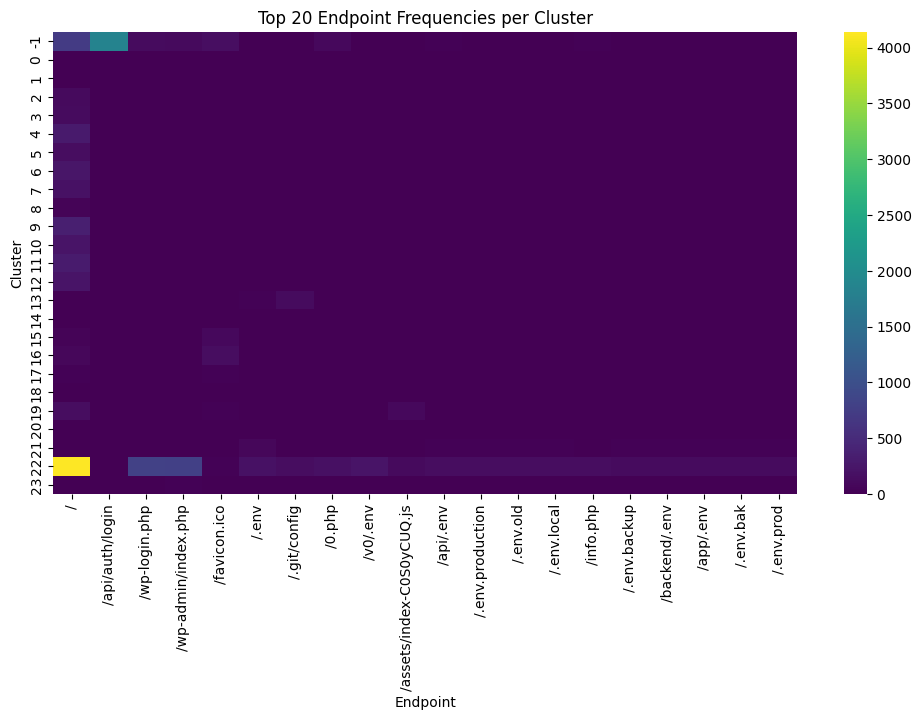

In [71]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Top 20 Endpoint Frequencies per Cluster")
plt.xlabel("Endpoint")
plt.ylabel("Cluster")
plt.show()


# Labelling Clusters

In [72]:
LABEL_RULES = [
    {
        "label": "WordPress exploitation / admin enumeration",
        "patterns": [
            r"^/wp-admin\b", r"^/wp-login\.php$", r"^/wp-includes\b",
            r"autoload_classmap\.php", r"classwithtostring\.php", r"wp-conflg\.php",
            r"xmlrpc\.php", r"wp-json", r"rest-api", r"colour\.php",
            r"wp-content/themes", r"wp-content/uploads", r"wp-content/plugins",
            r"wp-editor\.php", r"wp-the\.php", r"wp-admin\.php"
        ],
        "min_hits": 3
    },
    {
        "label": "PHPUnit RCE probing (eval-stdin.php)",
        "patterns": [r"phpunit", r"eval-stdin\.php"],
        "min_hits": 2
    },
    {
        "label": "Secrets discovery (.env harvesting)",
        "patterns": [
            r"\.env(\.|$)", r"/api/\.env", r"/apis/\.env", r"/nodeapi/\.env",
            r"\.env\.production", r"\.env\.local", r"\.env\.backup",
            r"\.env\.bak", r"\.env\.old", r"\.env\.staging",
            r"/backend/\.env", r"/app/\.env", r"/config/\.env",
            r"/public/\.env", r"/v0/\.env", r"status-page/env\.js"
        ],
        "min_hits": 2
    },
    {
        "label": "Git / source code exposure scan",
        "patterns": [
            r"\.git/config", r"\.git/HEAD", r"\.git/",
            r"admin/\.git", r"private/\.git"
        ],
        "min_hits": 1
    },
    {
        "label": "Swagger / OpenAPI docs enumeration",
        "patterns": [
            r"api-docs", r"swagger", r"openapi", r"/service/api-docs/?$",
            r"swagger\.json", r"api-docs/swagger\.json",
            r"actuator/gateway/routes", r"actuator/health"
        ],
        "min_hits": 1
    },
    {
        "label": "Generic login discovery / credential targeting",
        "patterns": [
            r"/login(\.|/|$)", r"login\.jsp", r"login\.html", r"login\.htm",
            r"/remote/login", r"/manage/account/login", r"login\.action",
            r"nidp/app/login", r"login\.aspx", r"logon\.aspx",
            r"logon\.html", r"/RDWeb/Pages"
        ],
        "min_hits": 2
    },
    {
        "label": "IoT / embedded device exploit scan",
        "patterns": [
            r"boaform/admin/formLogin", r"cgi-bin/authLogin\.cgi", r"cgi-bin/login\.cgi",
            r"/ssi\.cgi/Login\.htm", r"goform/webLogin", r"goform/formJsonAjaxReq",
            r"goform/Mail_Test", r"HNAP0", r"setup\.cgi", r"apply\.cgi",
            r"device\.rsp", r"GponForm/diag_Form", r"vpnsvc/connect\.cgi",
            r"/SDK/webLanguage", r"portal/redlion", r"/bins/"
        ],
        "min_hits": 1
    },
    {
        "label": "Exchange / Autodiscover / RDP probe",
        "patterns": [
            r"autodiscover/autodiscover\.json", r"ecp/Current/exporttool",
            r"developmentserver/metadatauploader", r"owa/auth/logon\.aspx",
            r"RDWeb/Pages", r"ReportServer"
        ],
        "min_hits": 1
    },
    {
        "label": "Path traversal / directory escape probe",
        "patterns": [
            r"%0e%0e", r"\.%0e/", r"cgi-bin/.*bin/sh",
            r"\.\./\.\./", r"etc/passwd", r"etc/shadow"
        ],
        "min_hits": 1
    },
    {
        "label": "GeoServer / infrastructure admin probe",
        "patterns": [
            r"geoserver/web", r"geoserver/wfs", r"hudson",
            r"server-status", r"/webui/"
        ],
        "min_hits": 1
    },
    {
        "label": "PHP webshell deployment / backdoor probe",
        "patterns": [
            r"lite\.php", r"ms\.php", r"css\.php", r"class-t\.api\.php",
            r"adminfuns\.php", r"ws\.php", r"archivarix\.cms\.php",
            r"0\.php", r"alive\.php", r"rxmsxln/indeex\.php",
            r"\.php$"
        ],
        "min_hits": 2
    },
    {
        "label": "Cisco / VPN / firewall probe",
        "patterns": [
            r"\+CSCOE\+/logon\.html", r"/api/sonicos/is-sslvpn-enabled",
            r"remote/login", r"vpnsvc"
        ],
        "min_hits": 1
    },
    {
        "label": "Cloud metadata / config exposure",
        "patterns": [
            r"\.streamlit/secrets\.toml", r"config\.json", r"config\.php",
            r"config\.js", r"attacker/docker-compose\.yml",
            r"cdn-cgi/trace", r"api\.ipify\.org"
        ],
        "min_hits": 1
    },
    {
        "label": "Favicon / robots.txt fingerprinting",
        "patterns": [
            r"^/favicon\.ico$", r"^/robots\.txt$",
            r"favicon\.ico/ads\.txt", r"favicon\.ico/sellers\.json",
            r"favicon\.ico/app-ads\.txt"
        ],
        "min_hits": 2
    },
    {
        "label": "SonicWall SSLVPN probe",
        "patterns": [r"/api/sonicos/is-sslvpn-enabled"],
        "min_hits": 1
    },
    {
        "label": "ACME challenge path abuse / odd probe",
        "patterns": [r"^/\.well-known/acme-challenge/.*wp-login\.php$"],
        "min_hits": 1
    },
    {
        "label": "PHP info / config discovery",
        "patterns": [
            r"phpinfo\.php", r"/v0/config/application",
            r"/config/application", r"/api/info\.php", r"^/info\.php$"
        ],
        "min_hits": 1
    },
    {
        "label": "Legitimate application traffic",
        "patterns": [
            r"^/assets/", r"index-C0S0yCUQ\.js", r"index-DcJm0M0\.css",
            r"matrix-BbH0tOju\.jpg", r"hero-movie-Fz0j0jIb\.jpg",
            r"avatar-CfdDV0H\.jpg", r"darkKnight-DocH0ym0\.jpg"
        ],
        "min_hits": 2
    },
]

# Helper functions (cluster summarization + scoring)

In [73]:
def cluster_top_paths_from_list(df, cluster_col="cluster", list_col="paths", topn=50):
    """
    For data where each row contains a list of paths (e.g., per client/time_window),
    explode into one path per row, then compute top paths per cluster.
    Returns dict: cluster -> list of (path, count)
    """
    tmp = df[[cluster_col, list_col]].copy()
    tmp = tmp.explode(list_col)
    tmp = tmp.dropna(subset=[list_col])

    # Ensure strings (sometimes paths can be non-str)
    tmp[list_col] = tmp[list_col].astype(str)

    out = {}
    for c, g in tmp.groupby(cluster_col):
        vc = g[list_col].value_counts().head(topn)
        out[c] = list(zip(vc.index.tolist(), vc.values.tolist()))
    return out

tops = cluster_top_paths_from_list(train_data, cluster_col="cluster", list_col="paths", topn=50)
list(tops.items())[:1]  # peek

def _flatten_to_strings(x):
    """Return a flat list of strings from x (string, list, nested list, etc.)."""
    if x is None:
        return []
    if isinstance(x, (str, bytes)):
        return [x.decode() if isinstance(x, bytes) else x]
    if isinstance(x, (list, tuple, set)):
        out = []
        for item in x:
            out.extend(_flatten_to_strings(item))
        return out
    # fallback: coerce to string
    return [str(x)]

def score_cluster(paths_counts, rule):
    """
    Score a cluster against a rule.

    paths_counts: list of (path_or_paths, count)
      where path_or_paths may be a str OR a list/nested list of str.
    """
    patterns = [re.compile(p, flags=re.I) for p in rule["patterns"]]
    hits = 0
    matched_patterns = set()
    matched_paths = 0

    for path_obj, cnt in paths_counts:
        # Convert path_obj into one or more strings
        path_list = _flatten_to_strings(path_obj)

        # If any of the strings match any pattern, count it once for this (path_obj, cnt)
        matched_this_item = False
        for path in path_list:
            for pat in patterns:
                if pat.search(path):
                    hits += cnt
                    matched_patterns.add(pat.pattern)
                    matched_paths += 1
                    matched_this_item = True
                    break
            if matched_this_item:
                break

    return hits, sorted(matched_patterns), matched_paths


def label_cluster_multitag(paths_counts, top_k=3, min_secondary_score=0.35):
    """
    Return primary label + a few secondary tags.
    min_secondary_score is relative to best score (0-1).
    """
    candidates = []
    total = sum(cnt for _, cnt in paths_counts) + 1e-9

    for rule in LABEL_RULES:
        hits, matched_patterns, matched_paths = score_cluster(paths_counts, rule)
        if hits <= 0:
            continue

        coverage = hits / total
        meets_min = hits >= rule["min_hits"]
        score = (1 if meets_min else 0) * 10 + coverage * 5 + matched_paths * 0.1

        candidates.append({
            "label": rule["label"],
            "score": score,
            "coverage": coverage,
            "hits": hits,
            "patterns": matched_patterns
        })

    if not candidates:
        return {
            "primary_label": "Uncategorized / miscellaneous scanning",
            "label_conf": 0.0,
            "matched_patterns": "",
            "secondary_labels": ""
        }

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    best = candidates[0]
    best_score = best["score"]

    # confidence same as before
    conf = min(1.0, best["coverage"] + (0.15 if best["hits"] >= 10 else 0.0))

    # Secondary tags: other labels close-ish to best
    secondary = []
    for c in candidates[1:]:
        rel = c["score"] / (best_score + 1e-9)
        if rel >= min_secondary_score:
            secondary.append(c["label"])
        if len(secondary) >= (top_k - 1):
            break

    return {
        "primary_label": best["label"],
        "label_conf": round(conf, 3),
        "matched_patterns": ", ".join(best["patterns"]),
        "secondary_labels": "; ".join(secondary)
    }


# Generate labels for all clusters

In [74]:
type(train_data.loc[0, "paths"]), train_data.loc[0, "paths"]



(list, ['/'])

In [75]:
# Get top paths for each cluster
tops = cluster_top_paths_from_list(train_data, cluster_col="cluster", list_col="paths", topn=50)

# Apply auto-labeling
labels = []
for c, paths_counts in tops.items():
    res = label_cluster_multitag(paths_counts)
    labels.append({
        "cluster": c,
        "cluster_label": res["primary_label"],
        "label_conf": res["label_conf"],
        "matched_patterns": res["matched_patterns"],
        "secondary_labels": res["secondary_labels"],
    })

cluster_labels = pd.DataFrame(labels).sort_values("cluster")
cluster_labels



,cluster,cluster_label,label_conf,matched_patterns,secondary_labels
0,-1,PHP webshell deployment / backdoor probe,0.376,"0\.php, \.php$",PHPUnit RCE probing (eval-stdin.php); Generic ...
1,0,Cloud metadata / config exposure,0.028,"attacker/docker-compose\.yml, config\.js",
2,1,IoT / embedded device exploit scan,0.861,/SDK/webLanguage,
3,2,PHP webshell deployment / backdoor probe,0.345,"0\.php, \.php$, adminfuns\.php, class-t\.api\....",WordPress exploitation / admin enumeration; Cl...
4,3,PHP webshell deployment / backdoor probe,0.029,"adminfuns\.php, ws\.php",Cloud metadata / config exposure
5,4,Uncategorized / miscellaneous scanning,0.000,,
6,5,Exchange / Autodiscover / RDP probe,0.229,"autodiscover/autodiscover\.json, developmentse...",Secrets discovery (.env harvesting); Generic l...
7,6,PHP webshell deployment / backdoor probe,0.024,"\.php$, ms\.php",
8,7,Exchange / Autodiscover / RDP probe,0.237,"RDWeb/Pages, ReportServer, autodiscover/autodi...",Generic login discovery / credential targeting
9,8,Cloud metadata / config exposure,0.020,api\.ipify\.org,


In [76]:
# Can be modified based on your org's risk model

SEVERITY = {
    "PHPUnit RCE probing (eval-stdin.php)": "High",
    "Secrets discovery (.env harvesting)": "High",
    "WordPress exploitation / admin enumeration": "Medium-High",
    "Swagger / OpenAPI docs enumeration": "Medium",
    "IoT / embedded device admin login scan": "Medium",
    "Generic login discovery / credential targeting": "Low-Medium",
    "Uncategorized / miscellaneous scanning": "Low",
}

cluster_labels["severity"] = cluster_labels["cluster_label"].map(SEVERITY).fillna("Low")
cluster_labels.sort_values(["severity", "label_conf"], ascending=[True, False])


,cluster,cluster_label,label_conf,matched_patterns,secondary_labels,severity
22,21,Secrets discovery (.env harvesting),0.848,\.env(\.|$),Cloud metadata / config exposure; Git / source...,High
21,20,Secrets discovery (.env harvesting),0.839,\.env(\.|$),PHP webshell deployment / backdoor probe; PHP ...,High
23,22,Secrets discovery (.env harvesting),0.458,\.env(\.|$),PHP webshell deployment / backdoor probe; Clou...,High
18,17,Favicon / robots.txt fingerprinting,0.882,"^/favicon\.ico$, ^/robots\.txt$",,Low
2,1,IoT / embedded device exploit scan,0.861,/SDK/webLanguage,,Low
19,18,PHP webshell deployment / backdoor probe,0.829,"0\.php, \.php$",WordPress exploitation / admin enumeration,Low
17,16,Favicon / robots.txt fingerprinting,0.820,"^/favicon\.ico$, ^/robots\.txt$",,Low
16,15,Favicon / robots.txt fingerprinting,0.805,"^/favicon\.ico$, favicon\.ico/ads\.txt, favico...",PHP webshell deployment / backdoor probe,Low
14,13,Git / source code exposure scan,0.774,\.git/config,GeoServer / infrastructure admin probe; Secret...,Low
20,19,Legitimate application traffic,0.606,"^/assets/, index-C0S0yCUQ\.js",Secrets discovery (.env harvesting); Cloud met...,Low


In [77]:
train_data = train_data.merge(
    cluster_labels[["cluster", "cluster_label", "label_conf", "secondary_labels"]],
    on="cluster",
    how="left"
)

train_data.head()

,client_ip,window_start,request_count,unique_paths,unique_methods,status_200,status_401,status_403,status_404,status_429,...,cluster,umap_x,umap_y,cluster_label_x,label_conf_x,secondary_labels_x,umap_z,cluster_label_y,label_conf_y,secondary_labels_y
0,1.24.16.102,2026-03-05 16:05:00+00:00,1,1,1,1,0,0,0,0,...,2,-0.821136,0.609017,Secrets discovery (.env harvesting),0.006,,20.436680,PHP webshell deployment / backdoor probe,0.345,WordPress exploitation / admin enumeration; Cl...
1,1.24.16.50,2026-02-28 10:15:00+00:00,2,1,1,2,0,0,0,0,...,3,19.817070,5.761913,Uncategorized / miscellaneous scanning,0.000,,4.494616,PHP webshell deployment / backdoor probe,0.029,Cloud metadata / config exposure
2,1.252.194.4,2026-02-28 20:30:00+00:00,2,1,1,0,0,0,0,0,...,9,17.603884,-8.445459,Secrets discovery (.env harvesting),0.005,,-1.571299,IoT / embedded device exploit scan,0.224,Exchange / Autodiscover / RDP probe; GeoServer...
3,1.55.210.222,2026-02-24 23:30:00+00:00,2,1,1,0,0,0,0,0,...,-1,-1.118075,-12.021180,Secrets discovery (.env harvesting),0.202,WordPress exploitation / admin enumeration; Ge...,5.534128,PHP webshell deployment / backdoor probe,0.376,PHPUnit RCE probing (eval-stdin.php); Generic ...
4,100.26.106.240,2026-02-28 14:25:00+00:00,2,1,1,2,0,0,0,0,...,17,-4.562672,10.612368,Uncategorized / miscellaneous scanning,0.000,,-12.496918,Favicon / robots.txt fingerprinting,0.882,


# Test Accuracy with test data set

In [78]:
# Make X_test dense the same way you did for X_train
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test

# Transform test into the SAME UMAP space
test_embedding = reducer.transform(X_test_dense)

test_data["umap_x"] = test_embedding[:, 0]
test_data["umap_y"] = test_embedding[:, 1]

test_data[["umap_x", "umap_y"]].head()



NameError: name 'X_test' is not defined

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances

# Centroids of TRAIN clusters in UMAP space (exclude noise)
train_centroids = (
    train_data[train_data["cluster"] != -1]
    .groupby("cluster")[["umap_x", "umap_y"]]
    .mean()
)

# Matrix of centroids
C = train_centroids[["umap_x", "umap_y"]].values
cluster_ids = train_centroids.index.values

# Distances from each test point to each centroid
Xt = test_data[["umap_x", "umap_y"]].values
D = pairwise_distances(Xt, C)

# nearest centroid index
nearest_idx = D.argmin(axis=1)
nearest_dists = D.min(axis=1)

# THRESHOLD: Mark top X% of most distant points as noise (-1)
# OR use: percentile of distances (e.g., 75th percentile = keep 75%, mark 25% as noise)
PERCENTILE_THRESHOLD = 85  # Keep bottom 85% by distance, mark top 15% as noise
DISTANCE_THRESHOLD = np.percentile(nearest_dists, PERCENTILE_THRESHOLD)

test_data["cluster_pred"] = cluster_ids[nearest_idx].copy()
test_data.loc[nearest_dists > DISTANCE_THRESHOLD, "cluster_pred"] = -1  # Mark far points as noise
test_data["cluster_pred_dist"] = nearest_dists

print(f"Distance threshold (at {PERCENTILE_THRESHOLD}th percentile): {DISTANCE_THRESHOLD:.4f}")
print(f"Min distance: {nearest_dists.min():.4f}, Max distance: {nearest_dists.max():.4f}")
print(f"Points marked as noise (-1): {(test_data['cluster_pred'] == -1).sum()} / {len(test_data)} ({100 * (test_data['cluster_pred'] == -1).sum() / len(test_data):.1f}%)")

test_data[["cluster_pred", "cluster_pred_dist"]].head(10)



Distance threshold (at 85th percentile): 5.1875
Min distance: 0.1051, Max distance: 7.4902
Points marked as noise (-1): 28 / 186 (15.1%)


,cluster_pred,cluster_pred_dist
49,-1,5.655680
581,11,1.109373
82,-1,5.655680
304,4,1.086424
109,12,0.532211
605,11,1.824816
268,1,0.659021
352,4,1.688986
327,13,0.441334
439,11,1.109373


In [ ]:
train_centroid = train_data.groupby("cluster")[["umap_x", "umap_y"]].mean()
test_centroid  = test_data.groupby("cluster_pred")[["umap_x", "umap_y"]].mean()

common = train_centroid.index.intersection(test_centroid.index)

drift = (train_centroid.loc[common] - test_centroid.loc[common]).abs()
drift["drift_score"] = np.sqrt(drift["umap_x"]**2 + drift["umap_y"]**2)

drift.sort_values("drift_score", ascending=False).head(20)


,umap_x,umap_y,drift_score
-1,22.548042,18.313814,29.048409
0,2.939017,3.706072,4.729989
9,0.097316,1.249210,1.252995
2,0.698700,0.083014,0.703614
4,0.617897,0.115074,0.628521
1,0.434124,0.395040,0.586958
8,0.091081,0.564826,0.572122
3,0.537624,0.028286,0.538368
11,0.365623,0.255234,0.445898
5,0.137323,0.134593,0.192284


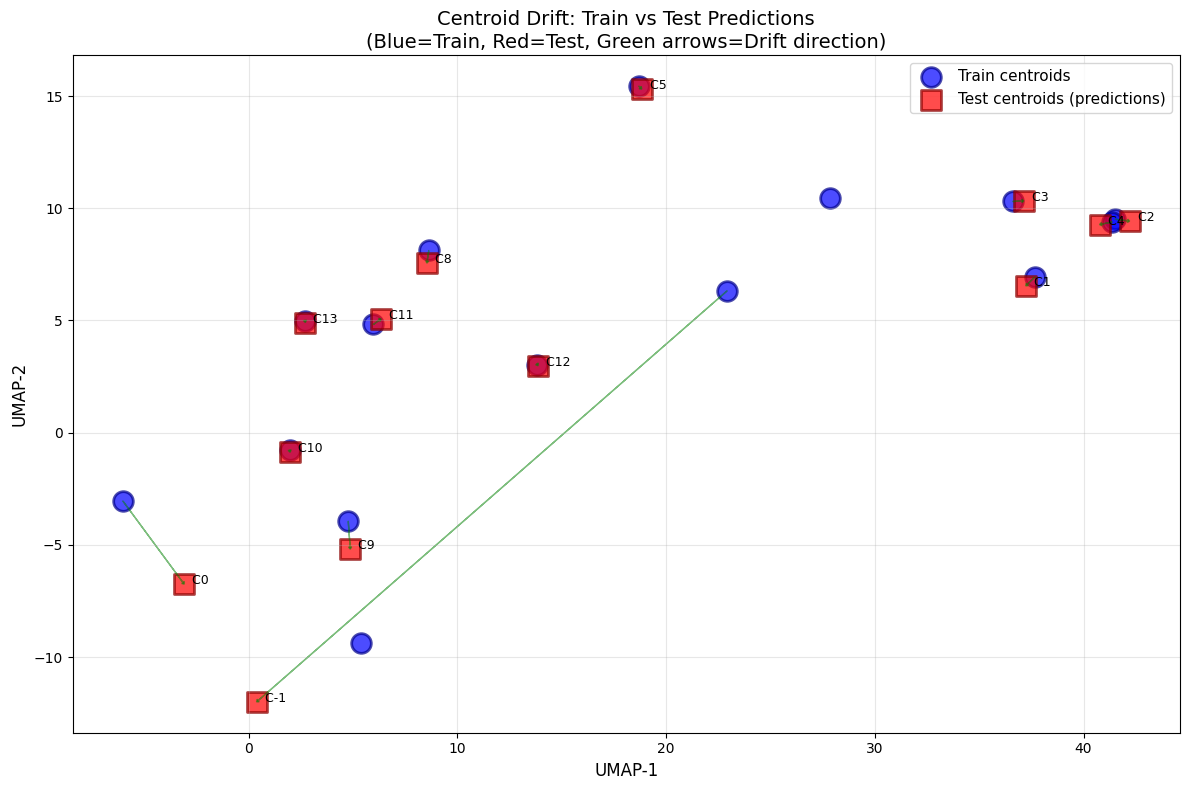

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 8))

# Plot train centroids
ax.scatter(train_centroid["umap_x"], train_centroid["umap_y"], 
          s=200, c="blue", marker="o", label="Train centroids", alpha=0.7, edgecolors="darkblue", linewidth=2)

# Plot test centroids
ax.scatter(test_centroid["umap_x"], test_centroid["umap_y"], 
          s=200, c="red", marker="s", label="Test centroids (predictions)", alpha=0.7, edgecolors="darkred", linewidth=2)

# Draw arrows showing drift for clusters in common
for cluster in common:
    train_x, train_y = train_centroid.loc[cluster, ["umap_x", "umap_y"]]
    test_x, test_y = test_centroid.loc[cluster, ["umap_x", "umap_y"]]
    
    # Arrow from train to test
    ax.arrow(train_x, train_y, test_x - train_x, test_y - train_y,
            head_width=0.15, head_length=0.1, fc="green", ec="green", alpha=0.5, length_includes_head=True)
    
    # Label the cluster
    ax.text(test_x, test_y, f"  C{cluster}", fontsize=9, ha="left")

# Formatting
ax.set_xlabel("UMAP-1", fontsize=12)
ax.set_ylabel("UMAP-2", fontsize=12)
ax.set_title("Centroid Drift: Train vs Test Predictions\n(Blue=Train, Red=Test, Green arrows=Drift direction)", fontsize=14)
ax.legend(fontsize=11, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Check if cluster -1 exists in both train and test predictions
print("Train clusters:", sorted(train_data["cluster"].unique()))
print("Test predicted clusters:", sorted(test_data["cluster_pred"].unique()))
print("\nCluster -1 in train:", -1 in train_data["cluster"].values)
print("Cluster -1 in test predictions:", -1 in test_data["cluster_pred"].values)


Train clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Test predicted clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

Cluster -1 in train: True
Cluster -1 in test predictions: True


In [ ]:
# Display cluster labels table
cluster_labels

,cluster,cluster_label,label_conf,matched_patterns,secondary_labels,severity
0,-1,WordPress exploitation / admin enumeration,0.660,"^/wp-admin\b, ^/wp-includes\b, ^/wp-login\.php...",Secrets discovery (.env harvesting); Generic l...,Medium-High
1,0,Secrets discovery (.env harvesting),0.421,\.env(\.|$),Generic login discovery / credential targeting...,High
2,1,WordPress exploitation / admin enumeration,1.000,"^/wp-admin\b, ^/wp-includes\b, ^/wp-login\.php$",,Medium-High
3,2,IoT / embedded device admin login scan,0.729,boaform/admin/formLogin,Secrets discovery (.env harvesting); PHP info/...,Medium
4,3,Secrets discovery (.env harvesting),0.955,\.env(\.|$),PHP info/config discovery,High
5,4,Generic login discovery / credential targeting,0.500,/login(\.|/|$),Secrets discovery (.env harvesting),Low-Medium
6,5,Generic login discovery / credential targeting,1.000,/login(\.|/|$),,Low-Medium
7,6,Generic login discovery / credential targeting,1.000,/login(\.|/|$),IoT / embedded device admin login scan; Secret...,Low-Medium
8,7,Swagger / OpenAPI docs enumeration,0.893,api-docs,Generic login discovery / credential targeting...,Medium
9,8,WordPress exploitation / admin enumeration,1.000,"^/wp-admin\b, ^/wp-includes\b, ^/wp-login\.php$",,Medium-High


In [ ]:
# Map cluster -> label from train
cluster_to_label = (
    train_data[["cluster", "cluster_label"]]
    .drop_duplicates()
    .set_index("cluster")["cluster_label"]
    .to_dict()
)

test_data["pred_label"] = test_data["cluster_pred"].map(cluster_to_label).fillna("Unknown / New")

test_data["pred_label"].value_counts()


pred_label
WordPress exploitation / admin enumeration        103
Secrets discovery (.env harvesting)                36
Generic login discovery / credential targeting     31
PHPUnit RCE probing (eval-stdin.php)               12
IoT / embedded device admin login scan              4
Name: count, dtype: int64

In [ ]:
ART = Path("Trained-model Artifacts")
ART.mkdir(exist_ok=True)

labels_train = train_data["cluster"].values

joblib.dump(hdb,          ART / "hdbscan.joblib")
joblib.dump(tfidf,        ART / "tfidf.joblib")
joblib.dump(scaler,       ART / "scaler.joblib")
joblib.dump(num_cols,     ART / "num_cols.joblib")
joblib.dump(X_train,      ART / "X_train.joblib")
joblib.dump(labels_train, ART / "labels_train.joblib")

print("Saved: hdbscan, tfidf, scaler, num_cols, X_train, labels_train")
print(f"Path: {ART.resolve()}")

In [ ]:
nn_index = NearestNeighbors(n_neighbors=1, metric='cosine', algorithm='brute')
nn_index.fit(X_train)

joblib.dump(nn_index, ART / "nn_index.joblib")

print("Saved: nn_index")
print(f"\nAll 7 artifacts ready in: {ART.resolve()}")
print(f"X_train shape:     {X_train.shape}")
print(f"Labels (unique):   {sorted(set(labels_train))}")

# Test Cluster drift on larger dataset